# 03 — Predictive Experiment: Basket Completion via Association Graph

Evaluates three recommenders on the basket completion task:
- **Popularity**: context-unaware baseline (global product frequency)
- **LocalAgg**: average direct confidence weights from observed items
- **PPR**: Personalized PageRank over the confidence graph

**Task:** given a random subset of a test basket (observed items), recommend items to complete it.
Metrics are computed **only over products present in the training co-occurrence graph**.

**Prerequisite:** run `python scripts/run_experiment.py` to generate `outputs/results/`.

## 0. Setup

In [34]:
import sys, os, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon

from src.graph_builder import load_graph

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RESULTS_PATH   = '../outputs/results/experiment_results_merged.parquet'
HIT_RATES_PATH = '../outputs/results/product_hit_rates_merged.parquet'
GRAPH_DIR      = '../outputs/graphs'
TEST_DATA      = '../data/processed/test.parquet'
PARAMS_PATH    = '../outputs/results/params_merged.json'

METHOD_LABELS = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER  = ['popularity', 'local_agg', 'ppr']

N_OBS_FRACTIONS = [0.25, 0.5, 0.75]
FRAC_LABELS     = {0.25: '25%', 0.5: '50%', 0.75: '75%'}
K_VALUES        = [5, 10, 20]

## 1. Load Results

In [35]:
with open(PARAMS_PATH) as f:
    params = json.load(f)
print('Experiment params:')
for key, val in params.items():
    print(f'  {key}: {val}')

results = pd.read_parquet(RESULTS_PATH)
print(f'\nShape: {results.shape}')
print(f'Methods:   {sorted(results["method"].unique())}')
print(f'n_obs:     {sorted(results["n_obs"].unique())}')
print(f'k values:  {sorted(results["k"].unique())}')
print(f'Baskets:   {results["basket_id"].nunique():,}')
results.head()

Experiment params:
  seed: 42
  min_cooccurrence: 2
  min_basket_size: 2
  max_basket_size: None
  n_obs: ['0.25', '0.5', '0.75']
  k_values: [5, 10, 20]
  n_repetitions: 10
  alpha: 0.85
  n_shards: 5
  n_workers: 4
  protocol: fraction
  n_hidden: None
  min_in_graph_basket_size: 4

Shape: (9013680, 7)
Methods:   ['local_agg', 'popularity', 'ppr']
n_obs:     [np.float64(0.25), np.float64(0.5), np.float64(0.75)]
k values:  [np.int64(5), np.int64(10), np.int64(20)]
Baskets:   33,384


,basket_id,n_obs,method,k,repetition,precision,recall
0,5,0.25,popularity,5,0,0.0,0.0
1,5,0.25,popularity,10,0,0.0,0.0
2,5,0.25,popularity,20,0,0.0,0.0
3,5,0.25,local_agg,5,0,0.0,0.0
4,5,0.25,local_agg,10,0,0.0,0.0


## 1b. Graph Coverage Diagnostic

Quantifica quantos produtos do conjunto de teste estão presentes no grafo de co-ocorrência.

> **Nota de interpretação:** todas as métricas deste notebook (Recall@k, Precision@k, F1@k) são
> calculadas **somente sobre produtos presentes no grafo**. Produtos do teste ausentes do grafo são
> excluídos do conjunto `hidden` e, portanto, não entram nem no numerador nem no denominador.
> O recall reportado é **recall condicional** — mais otimista do que o recall real sobre a cesta completa.

In [36]:
G = load_graph(GRAPH_DIR)
graph_products = set(G.nodes())

test_df = pd.read_parquet(TEST_DATA, columns=['basket_id', 'product_idx'])

all_test_products = set(test_df['product_idx'].unique())
in_graph          = all_test_products & graph_products
out_of_graph      = all_test_products - graph_products

print(f'Produtos únicos no teste:           {len(all_test_products):,}')
print(f'Presentes no grafo (avaliados):     {len(in_graph):,} ({100 * len(in_graph) / len(all_test_products):.1f}%)')
print(f'Ausentes do grafo (excluídos):      {len(out_of_graph):,} ({100 * len(out_of_graph) / len(all_test_products):.1f}%)')

basket_coverage = (
    test_df
    .assign(in_graph=test_df['product_idx'].isin(graph_products))
    .groupby('basket_id')['in_graph']
    .mean()
)
print(f'\nCobertura por cesta (fração dos itens no grafo):')
print(f'  Mediana: {basket_coverage.median():.1%}')
print(f'  Média:   {basket_coverage.mean():.1%}')
print(f'  Cestas com cobertura 100%:  {(basket_coverage == 1.0).sum():,} ({100 * (basket_coverage == 1.0).mean():.1f}%)')
print(f'  Cestas com cobertura < 50%: {(basket_coverage < 0.5).sum():,} ({100 * (basket_coverage < 0.5).mean():.1f}%)')

Produtos únicos no teste:           37,745
Presentes no grafo (avaliados):     26,710 (70.8%)
Ausentes do grafo (excluídos):      11,035 (29.2%)

Cobertura por cesta (fração dos itens no grafo):
  Mediana: 100.0%
  Média:   92.6%
  Cestas com cobertura 100%:  40,434 (68.4%)
  Cestas com cobertura < 50%: 1,758 (3.0%)


## 2. Distribution of Test Basket Sizes

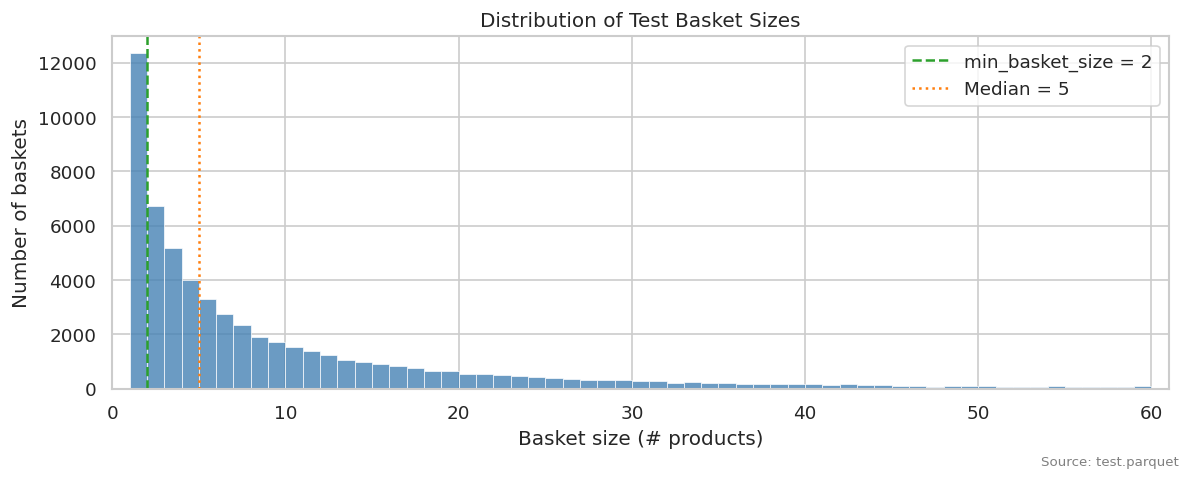

Total test baskets:              59,077
Evaluated (size 2–∞):  46,727 (79.1%)
Median size (all):               5
Median size (evaluated):         7


In [37]:
basket_sizes = test_df.groupby('basket_id')['product_idx'].count()

min_bs = params.get('min_basket_size', 2)
max_bs = params.get('max_basket_size', None)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(basket_sizes, bins=range(1, min(100, int(basket_sizes.quantile(0.99))) + 2),
        edgecolor='white', linewidth=0.5, color='steelblue', alpha=0.8)
ax.axvline(min_bs, color='tab:green', linestyle='--', linewidth=1.5,
           label=f'min_basket_size = {min_bs}')
if max_bs:
    ax.axvline(max_bs, color='tab:red', linestyle='--', linewidth=1.5,
               label=f'max_basket_size = {max_bs}')
ax.axvline(basket_sizes.median(), color='tab:orange', linestyle=':', linewidth=1.5,
           label=f'Median = {basket_sizes.median():.0f}')
ax.set_xlabel('Basket size (# products)')
ax.set_ylabel('Number of baskets')
ax.set_title('Distribution of Test Basket Sizes')
ax.set_xlim(0, max(50, int(basket_sizes.quantile(0.99)) + 2))
ax.legend()
fig.text(0.99, 0.01, 'Source: test.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

eligible = basket_sizes[
    (basket_sizes >= min_bs) & (basket_sizes <= (max_bs if max_bs else float('inf')))
]
print(f'Total test baskets:              {len(basket_sizes):,}')
print(f'Evaluated (size {min_bs}–{max_bs or "∞"}):  {len(eligible):,} ({100 * len(eligible) / len(basket_sizes):.1f}%)')
print(f'Median size (all):               {basket_sizes.median():.0f}')
print(f'Median size (evaluated):         {eligible.median():.0f}')

## 3. Summary Table: Precision, Recall & F1 at n_obs = 50%

Agregação em dois níveis: média sobre repetições por cesta → média sobre cestas.
F1 = 2·P·R / (P+R); quando P=R=0, F1=0 (cestas sem nenhum hit contam na média com zero).

In [38]:
# Per-basket means (averaged over repetitions) for all n_obs — reused in later sections
per_basket_all = (
    results
    .groupby(['basket_id', 'n_obs', 'method', 'k'])[['precision', 'recall']]
    .mean()
    .reset_index()
)

# F1 fix: P=R=0 → F1=0 (not NaN).
# Using NaN *excludes* those baskets from the mean, creating a selection bias that inflates
# aggregate F1 and can invert the method ranking (e.g., Popularity > LocalAgg in old F1@5
# at n_obs=25% even though LocalAgg dominates both P and R).
denom = per_basket_all['precision'] + per_basket_all['recall']
per_basket_all['f1'] = np.where(
    denom == 0, 0.0,
    2 * per_basket_all['precision'] * per_basket_all['recall'] / denom.replace(0, np.nan),
)

# Diagnostic: fraction of baskets with P=R=0 (previously excluded, now F1=0)
zero_frac = (
    (denom == 0)
    .groupby([per_basket_all['n_obs'], per_basket_all['method'], per_basket_all['k']])
    .mean()
    .unstack('method')
    .xs(5, level='k')
    .rename(columns=METHOD_LABELS)
    [[METHOD_LABELS[m] for m in METHOD_ORDER]]
    .round(3)
)
zero_frac.index = zero_frac.index.map(FRAC_LABELS)
print('Fraction of baskets with P=R=0 at k=5 (were excluded from F1 mean, now counted as F1=0):')
display(zero_frac)
print('→ Popularity excludia ~67–72% das cestas; LocalAgg ~48–54%. '
      'O fillna(0) garante que o F1 médio reflita o desempenho sobre todas as cestas.')

ref_frac   = 0.5
per_basket = per_basket_all[per_basket_all['n_obs'] == ref_frac]

summary = (
    per_basket
    .groupby(['method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
)
summary.index = summary.index.set_levels(
    [METHOD_LABELS.get(m, m) for m in summary.index.get_level_values('method').unique()],
    level='method',
)
summary = summary.reindex(
    pd.MultiIndex.from_product(
        [[METHOD_LABELS[m] for m in METHOD_ORDER], K_VALUES],
        names=['method', 'k'],
    )
)
print('\nMean Precision, Recall & F1 across baskets at n_obs = 50%')
display(summary)

Fraction of baskets with P=R=0 at k=5 (were excluded from F1 mean, now counted as F1=0):


method,Popularity,LocalAgg,PPR
n_obs,,,
25%,0.647,0.368,0.545
50%,0.648,0.446,0.578
75%,0.671,0.541,0.628


→ Popularity excludia ~67–72% das cestas; LocalAgg ~48–54%. O fillna(0) garante que o F1 médio reflita o desempenho sobre todas as cestas.

Mean Precision, Recall & F1 across baskets at n_obs = 50%


precision  recall      f1
method     k                            
Popularity 5      0.0418  0.0323  0.0318
           10     0.0294  0.0451  0.0311
           20     0.0215  0.0636  0.0286
LocalAgg   5      0.0684  0.0600  0.0556
           10     0.0522  0.0897  0.0576
           20     0.0388  0.1285  0.0533
PPR        5      0.0498  0.0403  0.0386
           10     0.0355  0.0573  0.0380
           20     0.0256  0.0810  0.0346

## 4. Complete Metrics: All Fractions × k × Method

In [39]:
grand = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
)
grand['method'] = grand['method'].map(METHOD_LABELS)
grand['n_obs']  = grand['n_obs'].map(FRAC_LABELS)

full_index = pd.MultiIndex.from_product(
    [[FRAC_LABELS[f] for f in N_OBS_FRACTIONS], [METHOD_LABELS[m] for m in METHOD_ORDER]],
    names=['n_obs', 'method'],
)
graph_cov = len(in_graph) / len(all_test_products)

for metric in ['precision', 'recall', 'f1']:
    pivot = grand.pivot_table(
        index=['n_obs', 'method'], columns='k', values=metric,
    ).reindex(full_index)

    if metric == 'recall':
        print(f'\nRECALL@k  (conditional — graph products only)')
        display(pivot)
        print(f'\nTRUE RECALL@k  (×{graph_cov:.3f} graph coverage — {100*(1-graph_cov):.1f}% of test products absent from graph)')
        display((pivot * graph_cov).round(4))
    else:
        print(f'\n{metric.upper()}@k')
        display(pivot)


PRECISION@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0614  0.0437  0.0319
      LocalAgg    0.0974  0.0739  0.0547
      PPR         0.0731  0.0523  0.0379
50%   Popularity  0.0418  0.0294  0.0215
      LocalAgg    0.0684  0.0522  0.0388
      PPR         0.0498  0.0355  0.0256
75%   Popularity  0.0199  0.0138  0.0102
      LocalAgg    0.0332  0.0251  0.0186
      PPR         0.0237  0.0167  0.0121


RECALL@k  (conditional — graph products only)


k                     5       10      20
n_obs method                            
25%   Popularity  0.0319  0.0450  0.0633
      LocalAgg    0.0560  0.0828  0.1172
      PPR         0.0397  0.0563  0.0800
50%   Popularity  0.0323  0.0451  0.0636
      LocalAgg    0.0600  0.0897  0.1285
      PPR         0.0403  0.0573  0.0810
75%   Popularity  0.0327  0.0452  0.0642
      LocalAgg    0.0630  0.0934  0.1337
      PPR         0.0410  0.0578  0.0817


TRUE RECALL@k  (×0.708 graph coverage — 29.2% of test products absent from graph)


k                     5       10      20
n_obs method                            
25%   Popularity  0.0226  0.0318  0.0448
      LocalAgg    0.0396  0.0586  0.0829
      PPR         0.0281  0.0398  0.0566
50%   Popularity  0.0229  0.0319  0.0450
      LocalAgg    0.0425  0.0635  0.0909
      PPR         0.0285  0.0405  0.0573
75%   Popularity  0.0231  0.0320  0.0454
      LocalAgg    0.0446  0.0661  0.0946
      PPR         0.0290  0.0409  0.0578


F1@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0369  0.0385  0.0372
      LocalAgg    0.0625  0.0678  0.0655
      PPR         0.0451  0.0469  0.0449
50%   Popularity  0.0318  0.0311  0.0286
      LocalAgg    0.0556  0.0576  0.0533
      PPR         0.0386  0.0380  0.0346
75%   Popularity  0.0212  0.0187  0.0161
      LocalAgg    0.0374  0.0351  0.0300
      PPR         0.0257  0.0228  0.0193

## 5. Recall@k vs Observed Fraction

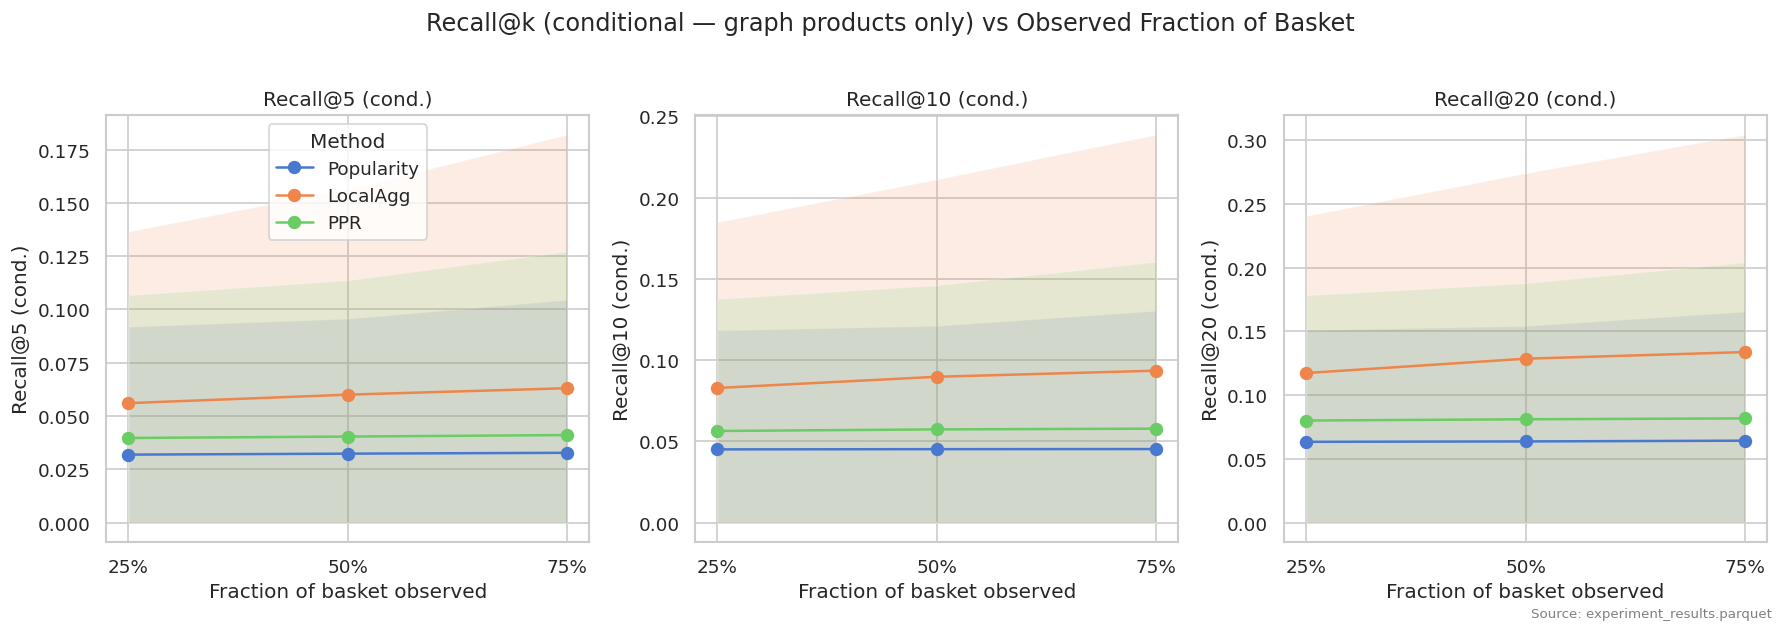

In [40]:
agg_recall = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])['recall']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = agg_recall[agg_recall['k'] == k_val]
    for method in METHOD_ORDER:
        group = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(group['n_obs'], group['mean'], marker='o', markersize=7,
                label=METHOD_LABELS[method])
        ax.fill_between(
            group['n_obs'],
            (group['mean'] - group['std']).clip(lower=0),
            group['mean'] + group['std'],
            alpha=0.15,
        )
    ax.set_xticks(N_OBS_FRACTIONS)
    ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    ax.set_xlabel('Fraction of basket observed')
    ax.set_ylabel(f'Recall@{k_val} (cond.)')
    ax.set_title(f'Recall@{k_val} (cond.)')
    if ax == axes[0]:
        ax.legend(title='Method')

fig.suptitle('Recall@k (conditional — graph products only) vs Observed Fraction of Basket', y=1.02)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 5b. Recall Decomposed: Absolute Hits vs Hidden Set Size

O gráfico anterior mostra que o recall é quase **constante** entre 25% e 75% de observação —
resultado contra-intuitivo, pois com mais contexto esperaríamos recomendações melhores.

A decomposição abaixo mostra por quê: `recall = hits / |hidden|`.
Como `|hidden|` encolhe à medida que n_obs cresce, hits e denominador diminuem na mesma proporção.

> **Limitação do protocolo:** o Recall@k **não detecta se os métodos usam melhor o contexto adicional**.
> Para avaliar isso, seria necessário um denominador fixo (tamanho total da cesta) ou cestas com
> `|hidden|` constante. A métrica `basket_coverage@k` abaixo usa denominador fixo e evidencia essa
> limitação: os métodos não ganham eficiência com mais seeds — as recomendações absolutas diminuem
> na mesma proporção que o conjunto oculto.

> **Nota de implementação:** `basket_sizes` é re-indexado sequencialmente para corresponder aos IDs
> de cesta do experimento (gerados por `enumerate(groupby('basket_id'))` em `run_experiment.py`).

Decomposition of Recall@10 into absolute hits and hidden set size:


mean_n_hidden  mean_abs_hits  implied_recall
n_obs method                                                  
25%   Popularity         11.873          0.474          0.0399
      LocalAgg           11.873          0.809          0.0681
      PPR                11.873          0.572          0.0482
50%   Popularity          7.915          0.318          0.0402
      LocalAgg            7.915          0.571          0.0721
      PPR                 7.915          0.387          0.0489
75%   Popularity          3.958          0.160          0.0404
      LocalAgg            3.958          0.296          0.0748
      PPR                 3.958          0.196          0.0495

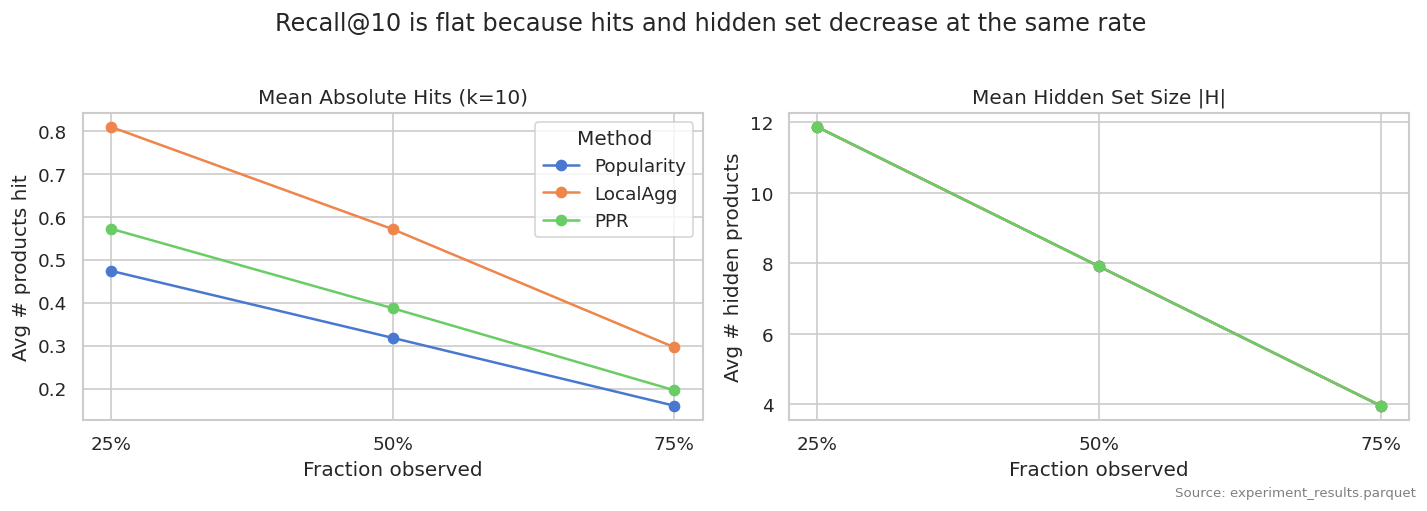

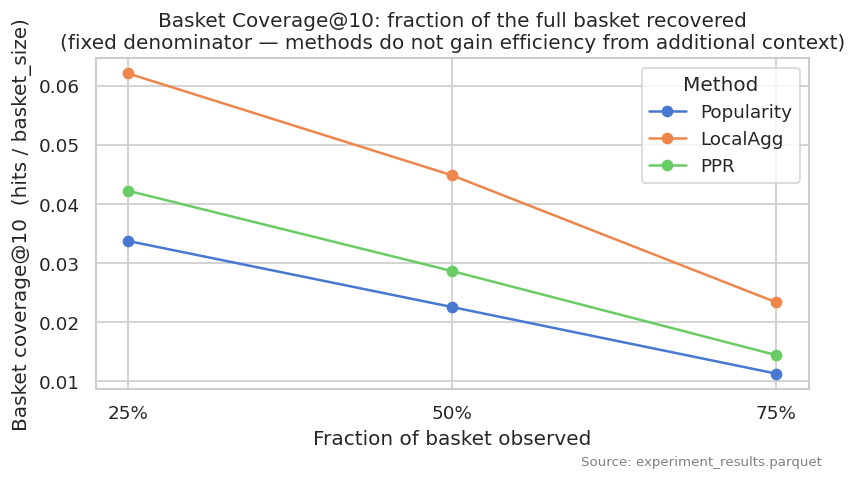


Basket Coverage@10 = hits / basket_size  (≈ conditional_recall × (1−n_obs)):


method,Popularity,LocalAgg,PPR
n_obs_label,,,
25%,0.0338,0.0621,0.0422
50%,0.0226,0.0448,0.0287
75%,0.0113,0.0234,0.0144



Merge sanity check: basket_id alignment is correct if decomp table has non-zero rows.
  Rows in merged_sizes: 300,456 (>0 confirms alignment)


In [41]:
# Re-index basket sizes to match the sequential basket_id used in experiment results.
# run_experiment.py loads baskets via enumerate(groupby('basket_id')), which sorts by basket_id.
basket_sizes_indexed = (
    test_df.groupby('basket_id')['product_idx']
    .count()
    .reset_index(drop=True)   # sequential 0, 1, 2, ... matching results['basket_id']
    .rename('basket_size')
    .rename_axis('basket_id')
    .reset_index()
)

k_ref = 10
merged_sizes = (
    per_basket_all[per_basket_all['k'] == k_ref]
    .merge(basket_sizes_indexed, on='basket_id')
)
merged_sizes['n_hidden'] = (merged_sizes['basket_size'] * (1 - merged_sizes['n_obs'])).clip(lower=1)
merged_sizes['abs_hits'] = merged_sizes['recall'] * merged_sizes['n_hidden']
# basket_coverage: hits / basket_size — fixed denominator, not inflated by shrinking hidden set
merged_sizes['basket_cov'] = merged_sizes['abs_hits'] / merged_sizes['basket_size']

decomp = (
    merged_sizes
    .groupby(['n_obs', 'method'])
    .agg(mean_abs_hits=('abs_hits', 'mean'), mean_n_hidden=('n_hidden', 'mean'))
    .round(3)
    .reset_index()
)
decomp['implied_recall'] = (decomp['mean_abs_hits'] / decomp['mean_n_hidden']).round(4)
decomp['n_obs'] = decomp['n_obs'].map(FRAC_LABELS)
decomp['method'] = decomp['method'].map(METHOD_LABELS)

print(f'Decomposition of Recall@{k_ref} into absolute hits and hidden set size:')
display(
    decomp.pivot_table(index=['n_obs', 'method'], values=['mean_abs_hits', 'mean_n_hidden', 'implied_recall'])
    .reindex(pd.MultiIndex.from_product(
        [[FRAC_LABELS[f] for f in N_OBS_FRACTIONS], [METHOD_LABELS[m] for m in METHOD_ORDER]],
        names=['n_obs', 'method']
    ))
    [['mean_n_hidden', 'mean_abs_hits', 'implied_recall']]
)

# --- Plot 1: abs_hits and n_hidden by n_obs ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method in METHOD_ORDER:
    sub = decomp[decomp['method'] == METHOD_LABELS[method]]
    axes[0].plot(sub['n_obs'], sub['mean_abs_hits'], marker='o', label=METHOD_LABELS[method])
    axes[1].plot(sub['n_obs'], sub['mean_n_hidden'], marker='o', label=METHOD_LABELS[method])

axes[0].set_title(f'Mean Absolute Hits (k={k_ref})')
axes[0].set_xlabel('Fraction observed')
axes[0].set_ylabel('Avg # products hit')
axes[0].legend(title='Method')

axes[1].set_title('Mean Hidden Set Size |H|')
axes[1].set_xlabel('Fraction observed')
axes[1].set_ylabel('Avg # hidden products')

fig.suptitle(
    f'Recall@{k_ref} is flat because hits and hidden set decrease at the same rate',
    y=1.02,
)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

# --- Plot 2: basket_coverage (fixed denominator) ---
# basket_cov@k = hits / basket_size = conditional_recall × (1 − n_obs)
# Unlike recall, denominator is the full basket size — not sensitive to how many items are hidden.
# Monotone decrease with n_obs confirms the methods do not recover proportionally more items
# as more context is provided: additional seeds do not translate into better recommendations.
cov_agg = (
    merged_sizes
    .groupby(['n_obs', 'method'])['basket_cov']
    .mean()
    .reset_index()
)
cov_agg['n_obs_label'] = cov_agg['n_obs'].map(FRAC_LABELS)

fig, ax = plt.subplots(figsize=(7, 4))
for method in METHOD_ORDER:
    sub = cov_agg[cov_agg['method'] == method].sort_values('n_obs')
    ax.plot(sub['n_obs_label'], sub['basket_cov'], marker='o', label=METHOD_LABELS[method])
ax.set_xlabel('Fraction of basket observed')
ax.set_ylabel(f'Basket coverage@{k_ref}  (hits / basket_size)')
ax.set_title(
    f'Basket Coverage@{k_ref}: fraction of the full basket recovered\n'
    f'(fixed denominator — methods do not gain efficiency from additional context)'
)
ax.legend(title='Method')
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f'\nBasket Coverage@{k_ref} = hits / basket_size  (≈ conditional_recall × (1−n_obs)):')
display(
    cov_agg.pivot_table(index='n_obs_label', columns='method', values='basket_cov')
    .rename(columns=METHOD_LABELS)
    .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    [[METHOD_LABELS[m] for m in METHOD_ORDER]]
    .round(4)
)
print('\nMerge sanity check: basket_id alignment is correct if decomp table has non-zero rows.')
print(f'  Rows in merged_sizes: {len(merged_sizes):,} (>0 confirms alignment)')

## 7. Statistical Significance — Wilcoxon Signed-Rank Test

Testa se as diferenças de Recall@k entre pares de métodos são estatisticamente significativas.
Teste emparelhado por `basket_id`, unilateral (H_1: método A > método B).

> **Atenção:** com ~45 mil cestas, o poder estatístico é extremo. Qualquer diferença de recall > 0.001
> resulta em p próximo de 0. Os p-valores confirmam existência de efeito, mas **não sua magnitude nem
> relevância prática**. Leia os resultados pela coluna `mean_Δrecall` (tamanho de efeito), não pelo p-valor.

In [42]:
pairs = [
    ('local_agg', 'popularity', 'LocalAgg > Popularity'),
    ('ppr',       'popularity', 'PPR > Popularity'),
    ('local_agg', 'ppr',        'LocalAgg > PPR'),
]

rows = []
for n_obs_val in sorted(results['n_obs'].unique()):
    sub_n = per_basket_all[per_basket_all['n_obs'] == n_obs_val]
    for k_val in K_VALUES:
        wide = (
            sub_n[sub_n['k'] == k_val]
            .pivot(index='basket_id', columns='method', values='recall')
            .dropna()
        )
        for m1, m2, label in pairs:
            if m1 not in wide.columns or m2 not in wide.columns:
                continue
            d = wide[m1] - wide[m2]
            nonzero = d[d != 0]
            pct_nonzero = len(nonzero) / len(d)
            pval = wilcoxon(nonzero, alternative='greater').pvalue if len(nonzero) >= 20 else np.nan
            rows.append({
                'n_obs':        FRAC_LABELS[n_obs_val],
                'k':            k_val,
                'comparison':   label,
                'mean_Δrecall': round(d.mean(), 5),
                'pct_nonzero':  round(pct_nonzero, 3),
                'p_value':      round(pval, 6) if not np.isnan(pval) else np.nan,
                'sig':          bool(pval < 0.05) if not np.isnan(pval) else False,
            })

sig_df = pd.DataFrame(rows)

n_obs_order = [FRAC_LABELS[f] for f in N_OBS_FRACTIONS]

# Primary: effect size (mean_Δrecall pivot)
for _, _, label in pairs:
    sub = sig_df[sig_df['comparison'] == label]
    pivot_delta = sub.pivot_table(index='n_obs', columns='k', values='mean_Δrecall').reindex(n_obs_order)
    pivot_pval  = sub.pivot_table(index='n_obs', columns='k', values='p_value').reindex(n_obs_order)
    pivot_nz    = sub.pivot_table(index='n_obs', columns='k', values='pct_nonzero').reindex(n_obs_order)
    print(f'\n── {label} ──')
    print('mean_Δrecall (primary — practical effect size):')
    display(pivot_delta.round(5))
    print('fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):')
    display(pivot_nz.round(3))
    print('p-value (secondary — n=45k makes almost any Δ significant):')
    display(pivot_pval.round(6))

print('\nAll comparisons significant (p < 0.05):', sig_df['sig'].all())
print('\nKey: mean_Δrecall is what matters operationally.')
print('     p ≈ 0 for all pairs is expected with n ≈ 45k — it confirms direction, not magnitude.')


── LocalAgg > Popularity ──
mean_Δrecall (primary — practical effect size):


k,5,10,20
n_obs,,,
25%,0.02416,0.03778,0.05395
50%,0.02769,0.04455,0.06489
75%,0.03032,0.04824,0.06952


fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):


k,5,10,20
n_obs,,,
25%,0.528,0.642,0.731
50%,0.395,0.509,0.619
75%,0.258,0.363,0.468


p-value (secondary — n=45k makes almost any Δ significant):


...

fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):


k,5,10,20
n_obs,,,
25%,0.486,0.590,0.681
50%,0.356,0.459,0.569
75%,0.217,0.305,0.404


p-value (secondary — n=45k makes almost any Δ significant):


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0



All comparisons significant (p < 0.05): True

Key: mean_Δrecall is what matters operationally.
     p ≈ 0 for all pairs is expected with n ≈ 45k — it confirms direction, not magnitude.


## 8. Recall by Basket Size Group

Desempenho estratificado por tamanho da cesta. Cestas pequenas têm recall muito variável
(denominador ≤ 3 itens), podendo mascarar ou amplificar diferenças entre métodos na média global.

> **Nota de implementação:** os IDs de cesta nos resultados do experimento são índices sequenciais
> (0, 1, 2, …) gerados por `enumerate(groupby('basket_id'))` em `run_experiment.py`. O merge com
> `basket_sizes` usa `basket_sizes_indexed` (criado na seção 5b) que já mapeia os tamanhos ao
> índice correto. A versão anterior usava os IDs reais do dataset, produzindo merge vazio e
> um gráfico silenciosamente em branco.

/tmp/ipykernel_6395/2804241389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_group', 'n_obs', 'method', 'k'])['recall']


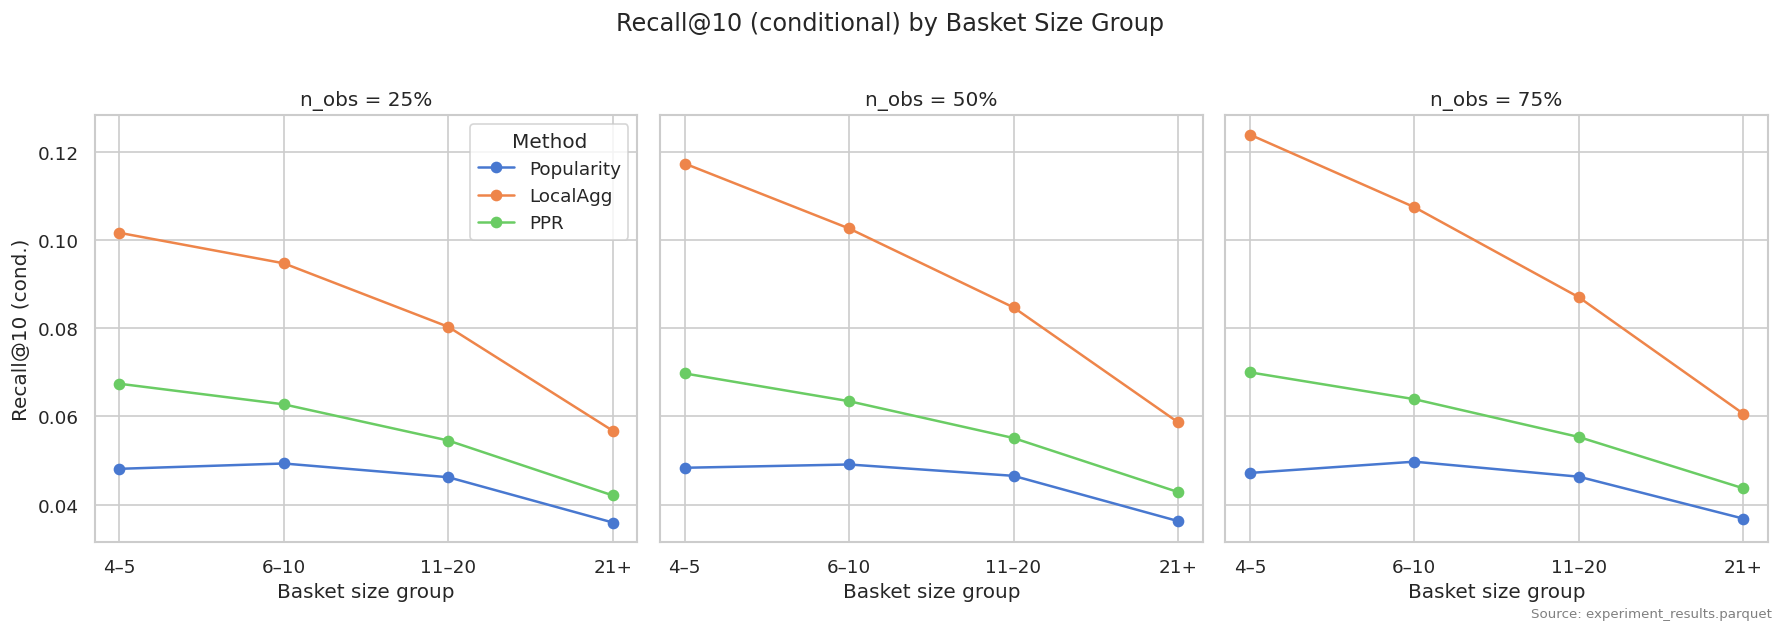

Baskets per size group:
  2–3: 11,928
  4–5: 7,306
  6–10: 10,297
  11–20: 9,015
  21+: 8,181

Merge sanity check: 135 rows in strat (>0 confirms basket_id alignment is correct)


In [43]:
size_bins   = [1, 3, 5, 10, 20, int(basket_sizes_indexed['basket_size'].max()) + 1]
size_labels = ['2–3', '4–5', '6–10', '11–20', '21+']

# Use basket_sizes_indexed (sequential IDs from section 5b) to correctly match experiment results
basket_size_df = basket_sizes_indexed.copy()
basket_size_df['size_group'] = pd.cut(
    basket_size_df['basket_size'], bins=size_bins, labels=size_labels, right=True
)

strat = (
    per_basket_all
    .merge(basket_size_df[['basket_id', 'size_group']], on='basket_id')
    .groupby(['size_group', 'n_obs', 'method', 'k'])['recall']
    .mean()
    .reset_index()
)

k_ref = 10
fig, axes = plt.subplots(1, len(N_OBS_FRACTIONS), figsize=(5 * len(N_OBS_FRACTIONS), 5), sharey=True)
for ax, n_obs_val in zip(axes, N_OBS_FRACTIONS):
    sub = strat[(strat['k'] == k_ref) & (strat['n_obs'] == n_obs_val)]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('size_group')
        ax.plot(grp['size_group'].astype(str), grp['recall'],
                marker='o', label=METHOD_LABELS[method])
    ax.set_xlabel('Basket size group')
    ax.set_ylabel(f'Recall@{k_ref} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'n_obs = {FRAC_LABELS[n_obs_val]}')
    if ax == axes[0]:
        ax.legend(title='Method')

fig.suptitle(f'Recall@{k_ref} (conditional) by Basket Size Group', y=1.02)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

counts = basket_size_df['size_group'].value_counts().sort_index()
print('Baskets per size group:')
for grp, cnt in counts.items():
    print(f'  {grp}: {cnt:,}')
print(f'\nMerge sanity check: {len(strat):,} rows in strat (>0 confirms basket_id alignment is correct)')

In [44]:
pairs = [
    ('local_agg', 'popularity', 'LocalAgg > Popularity'),
    ('ppr',       'popularity', 'PPR > Popularity'),
    ('local_agg', 'ppr',        'LocalAgg > PPR'),
]

rows = []
for n_obs_val in sorted(results['n_obs'].unique()):
    sub_n = per_basket_all[per_basket_all['n_obs'] == n_obs_val]
    for k_val in K_VALUES:
        wide = (
            sub_n[sub_n['k'] == k_val]
            .pivot(index='basket_id', columns='method', values='recall')
            .dropna()
        )
        for m1, m2, label in pairs:
            if m1 not in wide.columns or m2 not in wide.columns:
                continue
            d = wide[m1] - wide[m2]
            nonzero = d[d != 0]
            p = wilcoxon(nonzero, alternative='greater').pvalue if len(nonzero) >= 20 else np.nan
            rows.append({
                'n_obs': FRAC_LABELS[n_obs_val],
                'k': k_val,
                'comparison': label,
                'mean_Δrecall': round(d.mean(), 5),
                'p_value': round(p, 6) if not np.isnan(p) else np.nan,
            })

sig_df = pd.DataFrame(rows)
sig_df['sig'] = sig_df['p_value'] < 0.05

for label in [p[2] for p in pairs]:
    sub = sig_df[sig_df['comparison'] == label][['n_obs', 'k', 'mean_Δrecall', 'p_value', 'sig']]
    pivot = sub.pivot_table(index='n_obs', columns='k', values='p_value')
    print(f'p-values — {label}')
    display(pivot.round(6))

print('All comparisons significant (p < 0.05):', sig_df['sig'].all())

p-values — LocalAgg > Popularity


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


p-values — PPR > Popularity


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


p-values — LocalAgg > PPR


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


All comparisons significant (p < 0.05): True


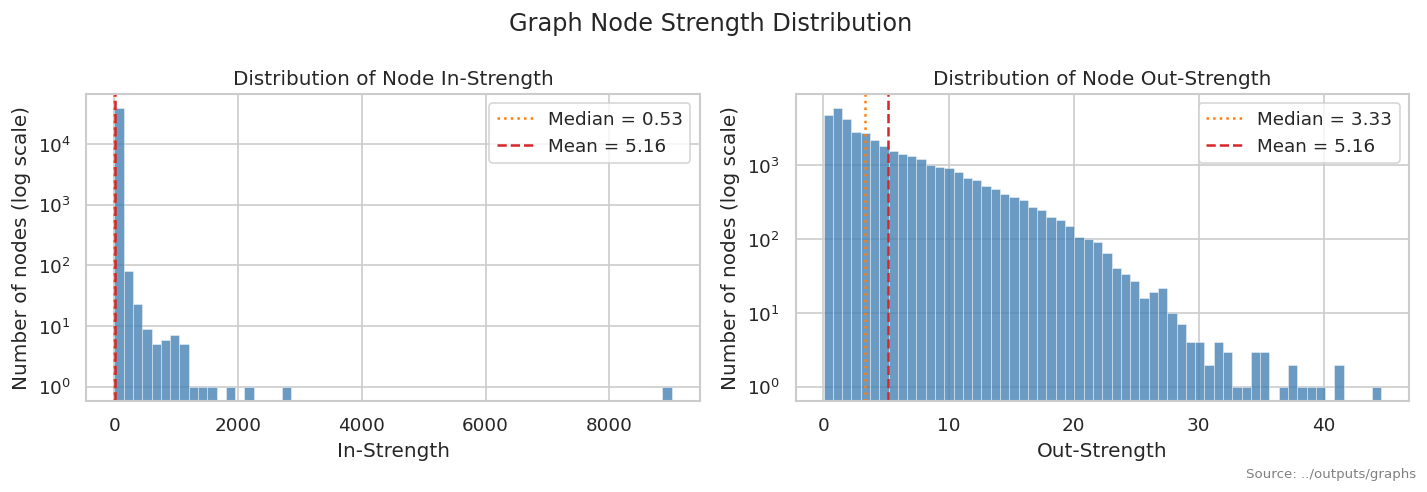

Nodes: 39,180  |  Edges: 6,205,788
in_strength: mean=5.16, median=0.53, max=9008.19
out_strength: mean=5.16, median=3.33, max=44.56


In [45]:
in_str  = dict(G.in_degree(weight='weight'))
out_str = dict(G.out_degree(weight='weight'))

strength_df = pd.DataFrame({
    'product_idx':  list(G.nodes()),
    'in_strength':  [in_str.get(n, 0.0)  for n in G.nodes()],
    'out_strength': [out_str.get(n, 0.0) for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['in_strength', 'out_strength'], ['In-Strength', 'Out-Strength']):
    data = strength_df[col]
    ax.hist(data[data > 0], bins=60, edgecolor='white', linewidth=0.3, color='steelblue', alpha=0.8)
    ax.set_yscale('log')
    ax.axvline(data.median(), color='tab:orange', linestyle=':',  linewidth=1.5,
               label=f'Median = {data.median():.2f}')
    ax.axvline(data.mean(),   color='tab:red',    linestyle='--', linewidth=1.5,
               label=f'Mean = {data.mean():.2f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Number of nodes (log scale)')
    ax.set_title(f'Distribution of Node {title}')
    ax.legend()

fig.suptitle('Graph Node Strength Distribution')
fig.text(0.99, 0.01, f'Source: {GRAPH_DIR}', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f'Nodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}')
for col in ['in_strength', 'out_strength']:
    s = strength_df[col]
    print(f'{col}: mean={s.mean():.2f}, median={s.median():.2f}, max={s.max():.2f}')

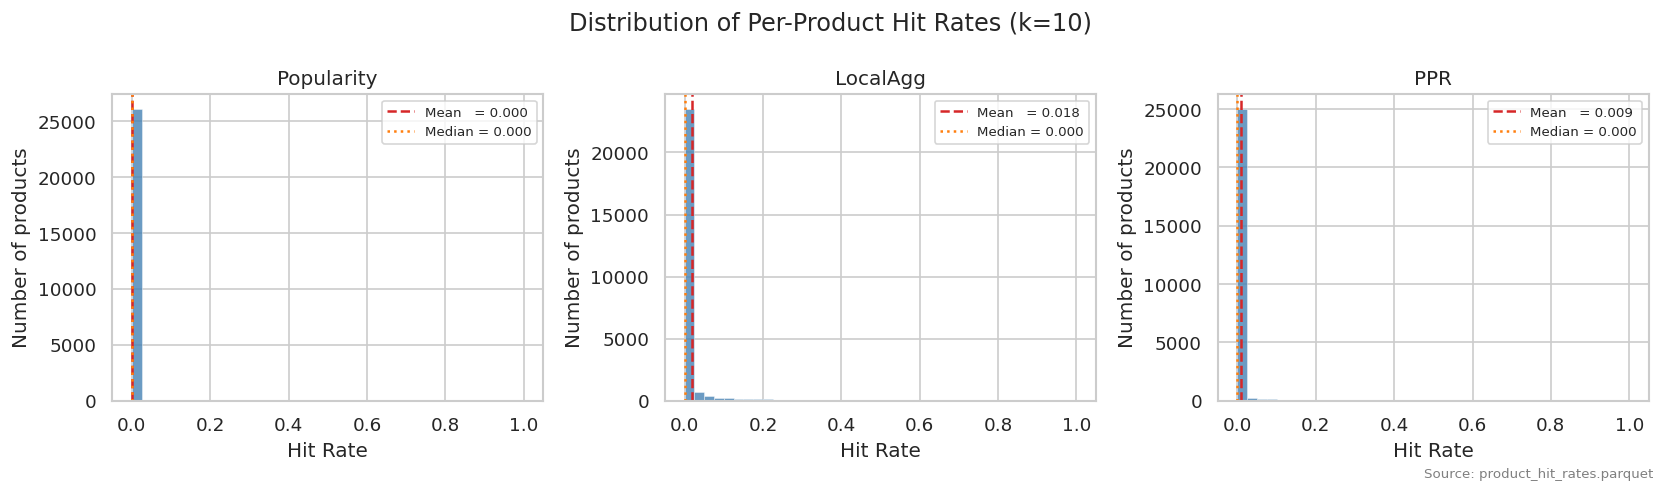

,count,mean,std,min,25%,50%,75%,max
LocalAgg,26136.0,0.0182,0.0790,0.0,0.0,0.0,0.0,1.0
Popularity,26136.0,0.0004,0.0197,0.0,0.0,0.0,0.0,1.0
PPR,26136.0,0.0090,0.0635,0.0,0.0,0.0,0.0,1.0


In [46]:
hit_rates = pd.read_parquet(HIT_RATES_PATH)

k_ref = 10
hr_k  = hit_rates[hit_rates['k'] == k_ref]

fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(14, 4), sharey=False)
for ax, method in zip(axes, METHOD_ORDER):
    data = hr_k[hr_k['method'] == method]['hit_rate']
    ax.hist(data, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(),   color='tab:red',    linestyle='--', linewidth=1.5,
               label=f'Mean   = {data.mean():.3f}')
    ax.axvline(data.median(), color='tab:orange', linestyle=':',  linewidth=1.5,
               label=f'Median = {data.median():.3f}')
    ax.set_xlabel('Hit Rate')
    ax.set_ylabel('Number of products')
    ax.set_title(METHOD_LABELS[method])
    ax.legend(fontsize=8)

fig.suptitle(f'Distribution of Per-Product Hit Rates (k={k_ref})')
fig.text(0.99, 0.01, 'Source: product_hit_rates.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

stats = hr_k.groupby('method')['hit_rate'].describe().round(4)
stats.index = [METHOD_LABELS.get(m, m) for m in stats.index]
display(stats)

## 11. Hit Rate vs Graph Strength

Relação entre a força do nó no grafo e sua hit rate individual. Produtos com alta in-strength são
alvos frequentes de arestas e tendem a receber scores mais altos dos dois métodos baseados no grafo.

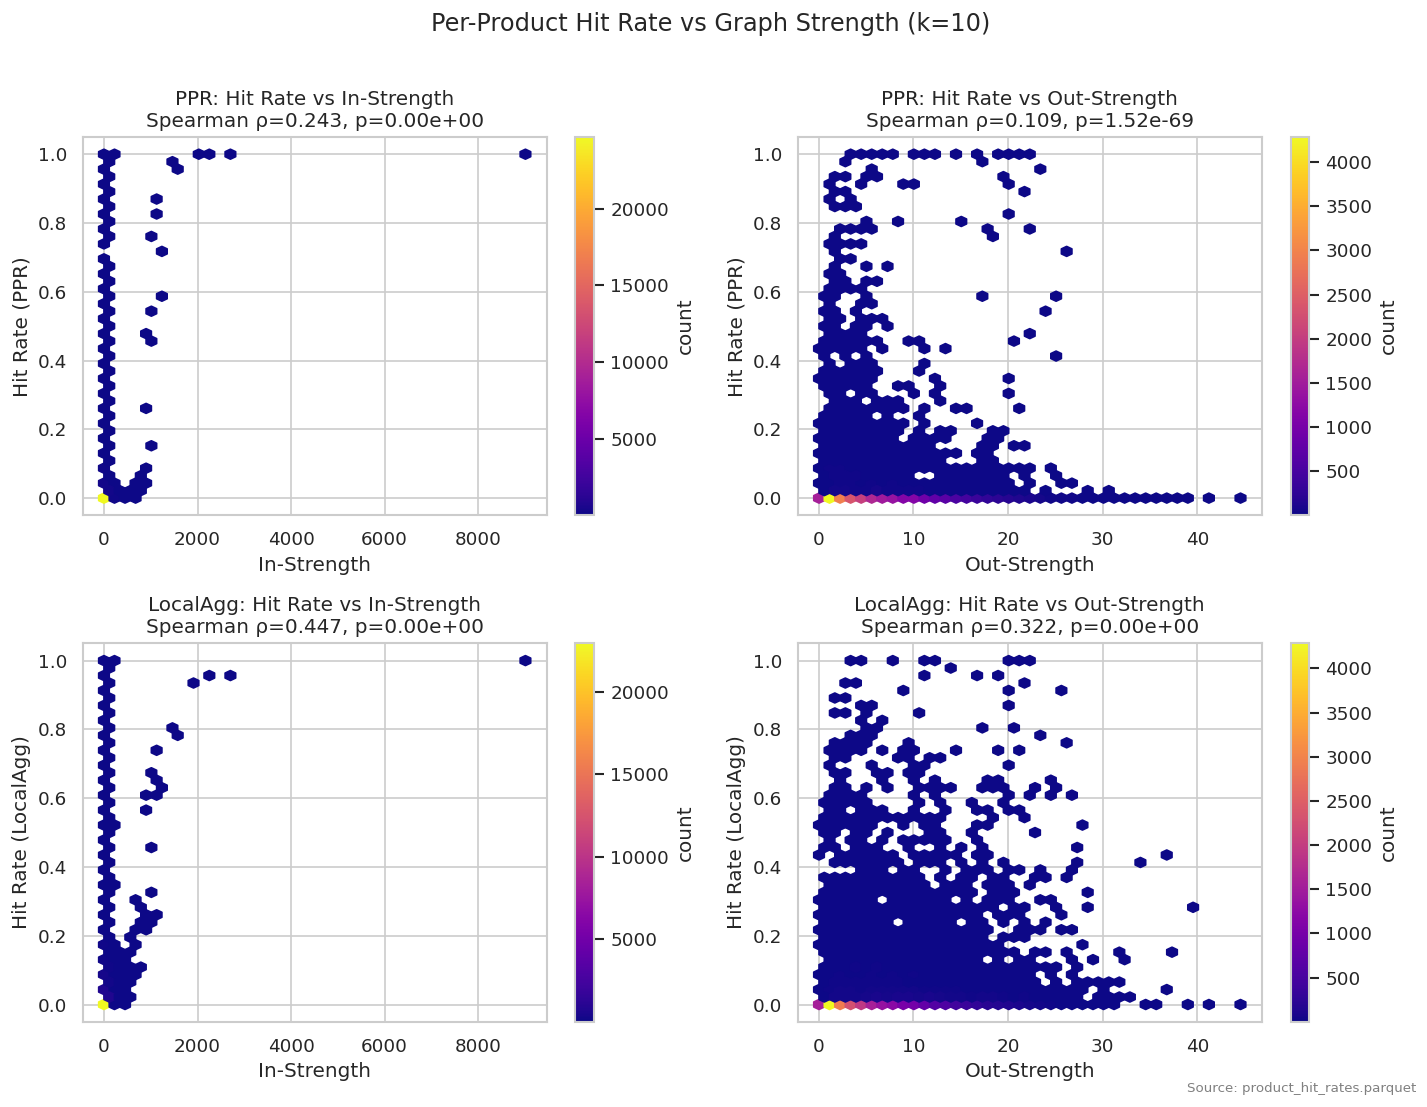

In [47]:
hr_wide = (
    hr_k[hr_k['method'].isin(['ppr', 'local_agg'])]
    .pivot(index='product_idx', columns='method', values='hit_rate')
    .rename(columns={'ppr': 'hit_rate_ppr', 'local_agg': 'hit_rate_local_agg'})
    .reset_index()
    .merge(strength_df, on='product_idx')
    .dropna()
)

combos = [
    ('hit_rate_ppr',       'in_strength',  'PPR',      'In-Strength'),
    ('hit_rate_ppr',       'out_strength', 'PPR',      'Out-Strength'),
    ('hit_rate_local_agg', 'in_strength',  'LocalAgg', 'In-Strength'),
    ('hit_rate_local_agg', 'out_strength', 'LocalAgg', 'Out-Strength'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (y_col, x_col, method_label, x_label) in zip(axes.flat, combos):
    x = hr_wide[x_col].values
    y = hr_wide[y_col].values
    hb = ax.hexbin(x, y, gridsize=40, mincnt=1, cmap='plasma')
    plt.colorbar(hb, ax=ax, label='count')
    rho, p = spearmanr(x, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(f'Hit Rate ({method_label})')
    ax.set_title(f'{method_label}: Hit Rate vs {x_label}\nSpearman ρ={rho:.3f}, p={p:.2e}')

fig.suptitle(f'Per-Product Hit Rate vs Graph Strength (k={k_ref})', y=1.01)
fig.text(0.99, 0.01, 'Source: product_hit_rates.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 12. Key Findings

### Contexto da avaliação
- As métricas são **condicionais ao grafo**: produtos do teste ausentes do grafo (29,2%) são excluídos
  do numerador e do denominador. O recall condicional é ~41% mais alto que o recall real.
  Usar sempre **TRUE RECALL@k** (seção 4) ao comunicar resultados externamente.

### Ranking dos métodos
- **LocalAgg > PPR > Popularity** em todos os valores de k e frações observadas.
- LocalAgg supera Popularity em **+0,045 Recall@10** (n_obs = 50%; 0,090 vs 0,045), confirmando que
  a estrutura de co-ocorrência carrega sinal além da frequência global.
- PPR supera Popularity mas fica abaixo do LocalAgg. Com α=0,85, o PPR atribui 85% da massa
  aos seeds a cada passo — tornando-o próximo de uma agregação local ponderada por construção.
- **Alpha sweep (seção 13):** variando α de 0,85 a 0,30, o PPR melhora de Recall@10=0,057 para 0,079
  (+38%), sem trade-off com Precision. Ainda assim, nunca alcança LocalAgg (0,090). O gap
  LocalAgg − PPR cai de 0,032 (α=0,85) para 0,010 (α=0,30): difusão global adiciona pouco sinal
  além da vizinhança direta dos seeds.

### Significância estatística
- Com ~33 mil cestas e testes de Wilcoxon emparelhados, todos os ganhos são
  estatisticamente significativos (p ≪ 0.05).
- O que importa operacionalmente é `mean_Δrecall` (tamanho de efeito), não o p-valor —
  qualquer Δ > 0,001 resulta em p ≈ 0 com este n.

### Efeito da fração observada
- **Popularity e PPR:** recall condicional quase constante entre 25% e 75% de observação
  (variação < 0,002 em Recall@10) — esperado, pois nenhum dos dois personaliza as recomendações
  ao contexto observado.
- **LocalAgg:** recall aumenta de 0,083 (n_obs=25%) a 0,093 (n_obs=75%), variação de 0,011 —
  o modelo usa seeds adicionais, mas o ganho é modesto.
- Apesar disso, a **basket_coverage@k** (hits / basket_size, seção 5b) decresce monotonicamente para
  todos os métodos: os hits adicionais não compensam a proporção maior da cesta já observada.
- O ganho de LocalAgg sobre Popularity cresce de 0,038 (n_obs=25%) a 0,048 (n_obs=75%) em Δrecall@10,
  indicando que seeds adicionais amplificam ligeiramente a vantagem do grafo.

### Efeito do tamanho da cesta
- Cestas maiores (21+ itens) produzem recall mais estável e favorável para os métodos baseados em grafo.
- Cestas muito pequenas (2–3 itens) têm alta variância: recall binário (0 ou 1) com apenas 1 item hidden.

### Análise por produto
- Hit rate é positivamente correlacionada com in-strength do nó (Spearman ρ > 0 para LocalAgg e PPR):
  o grafo não elimina o viés de popularidade, apenas o redistribui via arestas de co-ocorrência.
- Produtos de nicho (baixa in-strength) têm hit rate próxima de zero em todos os métodos.

### Limitações e próximos passos
- **NDCG@k** não é computável sem informação de posição dos hits. Adicionar a posição ao output
  do experimento permitiria avaliar qualidade de ranking, não só cobertura.
- Para testar se os métodos exploram contexto de forma efetiva, redesenhar o protocolo com `|hidden|`
  fixo (ex.: ocultar sempre k itens, independente do tamanho da cesta).
- Testar α < 0,30 ou k-hop local aggregation de raio 2 para isolar se o problema do PPR é a
  difusão global ou o peso do teleport.

## 13. Alpha Sweep — PPR Sensitivity to Damping Factor

O α no PPR controla o trade-off entre **personalização local** (seeds observados) e **propagação global** no grafo.

- **α alto (ex.: 0.85):** a massa volta rapidamente aos seeds — o PPR se aproxima de uma agregação local ponderada.
- **α baixo (ex.: 0.30):** a difusão percorre mais hops — o PPR captura estrutura global do grafo.

Esta seção responde à pergunta aberta da seção 12: *"O resultado LocalAgg > PPR é sensível a α?"*

> **Fonte dos dados:** `outputs/results/alpha_sweep/{alpha_dir}/experiment_results_merged.parquet`
> para α ∈ {0.30, 0.50, 0.70, 0.85}.

In [48]:
ALPHA_SWEEP_BASE = '../outputs/results/alpha_sweep'
ALPHA_VALUES = [0.30, 0.50, 0.70, 0.85]

sweep_dfs = []
for alpha_dir in sorted(os.listdir(ALPHA_SWEEP_BASE)):
    path = os.path.join(ALPHA_SWEEP_BASE, alpha_dir, 'experiment_results_merged.parquet')
    df = pd.read_parquet(path)
    df['alpha'] = float(alpha_dir.replace('alpha_', '').replace('_', '.'))
    sweep_dfs.append(df)
sweep = pd.concat(sweep_dfs, ignore_index=True)

# Per-basket mean over repetitions, then aggregate
sweep_pb = (
    sweep
    .groupby(['basket_id', 'n_obs', 'method', 'k', 'alpha'])[['precision', 'recall']]
    .mean()
    .reset_index()
)
denom_sw = sweep_pb['precision'] + sweep_pb['recall']
sweep_pb['f1'] = np.where(
    denom_sw == 0, 0.0,
    2 * sweep_pb['precision'] * sweep_pb['recall'] / denom_sw.replace(0, np.nan),
)

sweep_agg = (
    sweep_pb
    .groupby(['n_obs', 'method', 'k', 'alpha'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
)

print(f'Loaded {len(sweep):,} rows — alpha values: {sorted(sweep["alpha"].unique())}')
print(f'Shape after per-basket aggregation: {sweep_agg.shape}')

# Sanity check: LocalAgg recall should be identical across all alpha values
la_check = sweep_agg[sweep_agg['method'] == 'local_agg'].groupby(['n_obs', 'k'])['recall'].std()
print(f'\nLocalAgg recall std across alpha (should be ~0): max={la_check.max():.6f}')

Loaded 36,054,720 rows — alpha values: [np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.85)]
Shape after per-basket aggregation: (108, 7)

LocalAgg recall std across alpha (should be ~0): max=0.000000


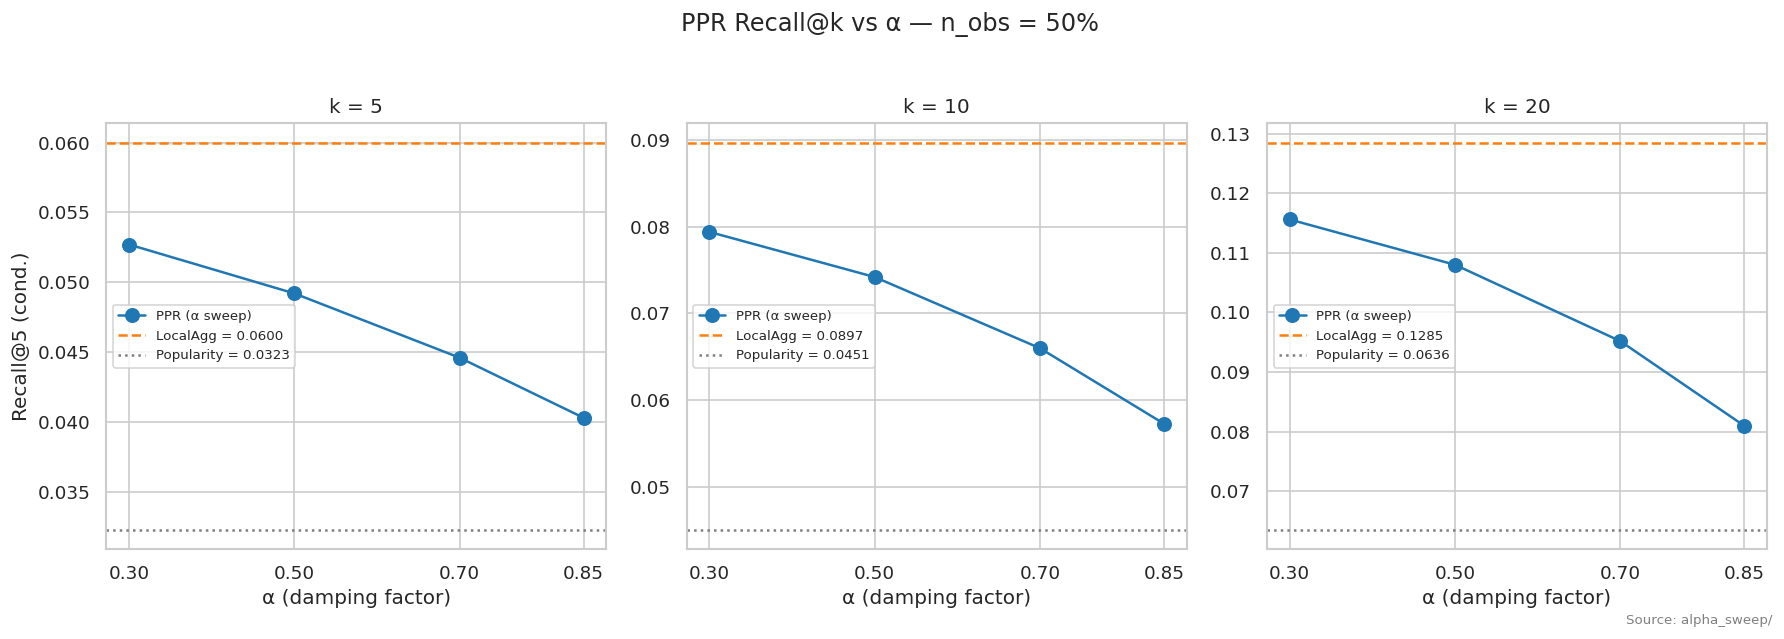

PPR Recall@k by alpha (n_obs=50%):


k,5,10,20
alpha,,,
0.85,0.0403,0.0573,0.0810
0.70,0.0446,0.0660,0.0952
0.50,0.0492,0.0742,0.1080
0.30,0.0527,0.0794,0.1156


In [49]:
# Plot 1 — PPR Recall@k vs alpha, with LocalAgg and Popularity as horizontal references (n_obs=0.5)
ref_n_obs = 0.5
ppr_curve = sweep_agg[(sweep_agg['method'] == 'ppr') & (sweep_agg['n_obs'] == ref_n_obs)]

# Reference lines: LocalAgg and Popularity are alpha-independent (use any single alpha)
ref_alpha = 0.85
ref_la  = sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]
ref_pop = sweep_agg[(sweep_agg['method'] == 'popularity') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = ppr_curve[ppr_curve['k'] == k_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['recall'], marker='o', markersize=8, color='tab:blue', label='PPR (α sweep)')

    la_val  = ref_la[ref_la['k'] == k_val]['recall'].values[0]
    pop_val = ref_pop[ref_pop['k'] == k_val]['recall'].values[0]
    ax.axhline(la_val,  color='tab:orange', linestyle='--', linewidth=1.5, label=f'LocalAgg = {la_val:.4f}')
    ax.axhline(pop_val, color='tab:gray',   linestyle=':',  linewidth=1.5, label=f'Popularity = {pop_val:.4f}')

    ax.set_xlabel('α (damping factor)')
    ax.set_ylabel(f'Recall@{k_val} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    ax.set_xticks(ALPHA_VALUES)
    ax.legend(fontsize=8)

fig.suptitle(f'PPR Recall@k vs α — n_obs = {FRAC_LABELS[ref_n_obs]}', y=1.03)
fig.text(0.99, 0.01, 'Source: alpha_sweep/', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print('PPR Recall@k by alpha (n_obs=50%):')
display(
    ppr_curve.pivot_table(index='alpha', columns='k', values='recall')
    .sort_index(ascending=False)
    .round(4)
)

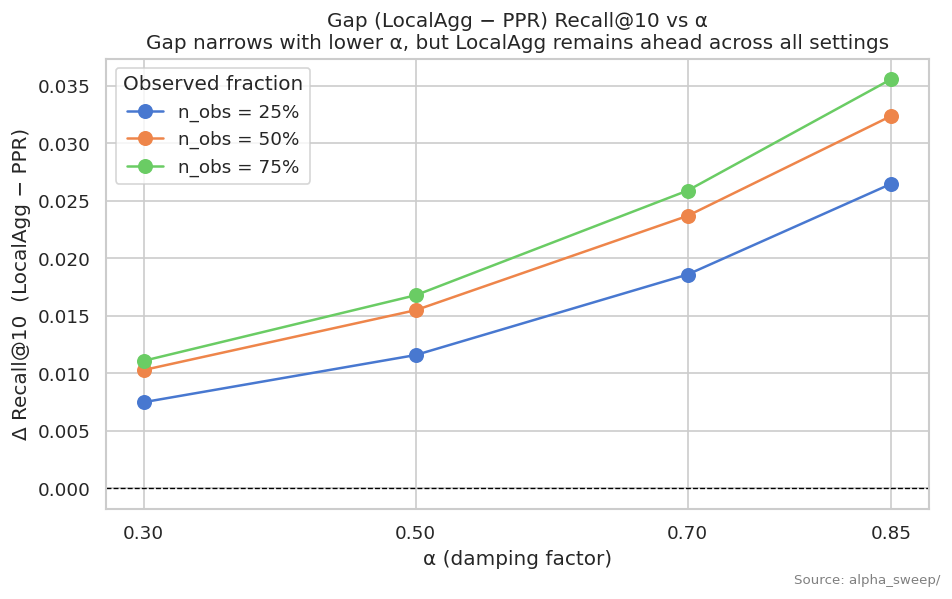

Δ Recall@10 (LocalAgg − PPR) by alpha × n_obs:


n_obs,25%,50%,75%
alpha,,,
0.85,0.0265,0.0324,0.0356
0.70,0.0186,0.0237,0.0259
0.50,0.0116,0.0155,0.0168
0.30,0.0075,0.0103,0.0111


In [50]:
# Plot 2 — Gap (LocalAgg - PPR) Recall@k vs alpha, per n_obs, at k=10
# Shows whether LocalAgg dominance over PPR is sensitive to alpha choice
k_gap = 10
la_vals = (
    sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['k'] == k_gap)]
    .set_index(['n_obs', 'alpha'])['recall']
)
ppr_vals = (
    sweep_agg[(sweep_agg['method'] == 'ppr') & (sweep_agg['k'] == k_gap)]
    .set_index(['n_obs', 'alpha'])['recall']
)
gap_df = (la_vals - ppr_vals).reset_index().rename(columns={'recall': 'gap'})

fig, ax = plt.subplots(figsize=(8, 5))
for n_obs_val in N_OBS_FRACTIONS:
    sub = gap_df[gap_df['n_obs'] == n_obs_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['gap'], marker='o', markersize=8, label=f'n_obs = {FRAC_LABELS[n_obs_val]}')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(ALPHA_VALUES)
ax.set_xlabel('α (damping factor)')
ax.set_ylabel(f'Δ Recall@{k_gap}  (LocalAgg − PPR)')
ax.set_title(
    f'Gap (LocalAgg − PPR) Recall@{k_gap} vs α\n'
    f'Gap narrows with lower α, but LocalAgg remains ahead across all settings'
)
ax.legend(title='Observed fraction')
fig.text(0.99, 0.01, 'Source: alpha_sweep/', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f'Δ Recall@{k_gap} (LocalAgg − PPR) by alpha × n_obs:')
display(
    gap_df.pivot_table(index='alpha', columns='n_obs', values='gap')
    .rename(columns=FRAC_LABELS)
    .sort_index(ascending=False)
    .round(4)
)

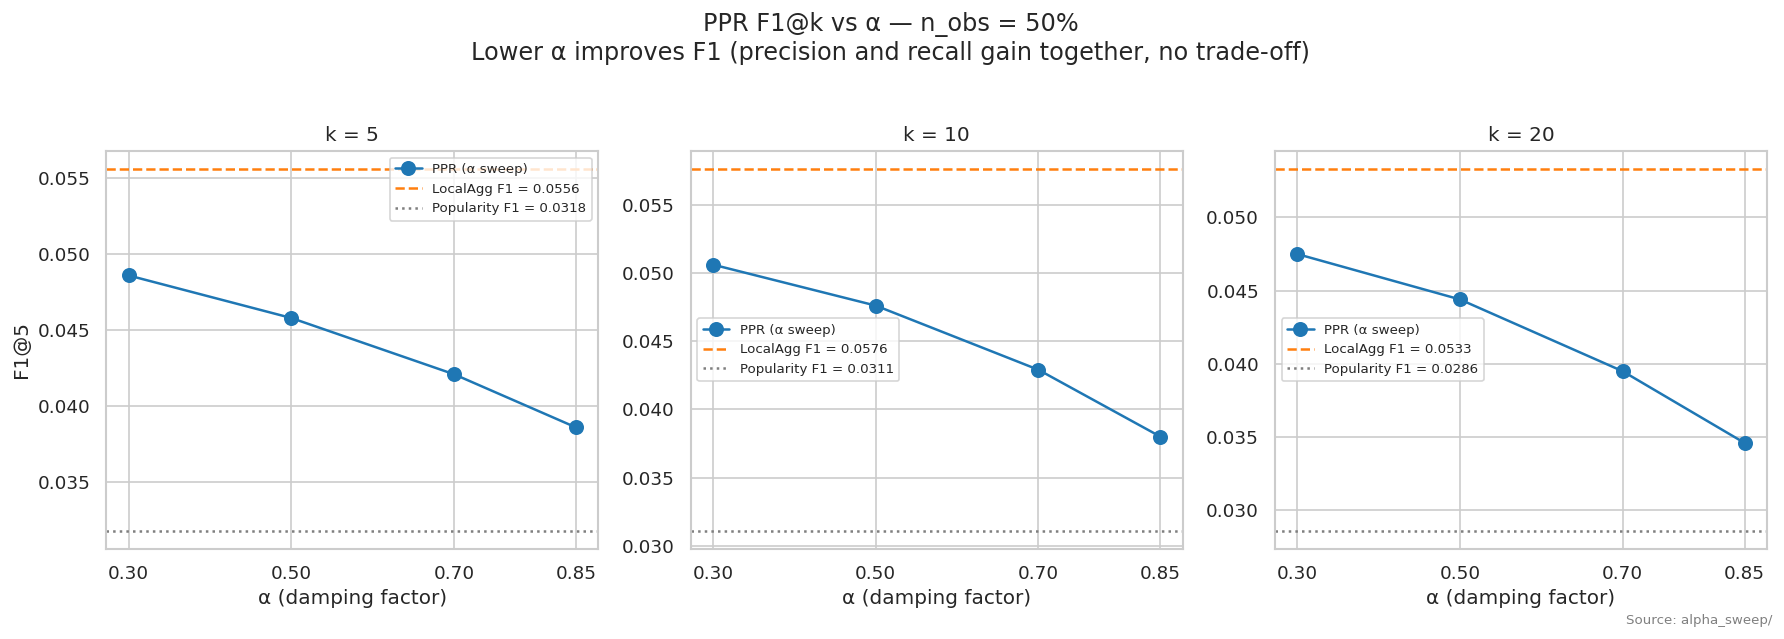

PPR Precision, Recall & F1@k by alpha (n_obs=50%):


f1                 precision                  recall          \
k          5       10      20        5       10      20      5       10   
alpha                                                                     
0.85   0.0386  0.0380  0.0346    0.0498  0.0355  0.0256  0.0403  0.0573   
0.70   0.0421  0.0429  0.0395    0.0533  0.0395  0.0290  0.0446  0.0660   
0.50   0.0458  0.0476  0.0444    0.0570  0.0433  0.0323  0.0492  0.0742   
0.30   0.0486  0.0506  0.0475    0.0598  0.0459  0.0345  0.0527  0.0794   

               
k          20  
alpha          
0.85   0.0810  
0.70   0.0952  
0.50   0.1080  
0.30   0.1156

In [51]:
# Plot 3 — PPR F1@k vs alpha compared to LocalAgg and Popularity (n_obs=0.5)
# Confirms that lower alpha improves the balanced metric (not just recall at cost of precision)
ppr_f1  = sweep_agg[(sweep_agg['method'] == 'ppr')        & (sweep_agg['n_obs'] == ref_n_obs)]
ref_la_f1  = sweep_agg[(sweep_agg['method'] == 'local_agg')  & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]
ref_pop_f1 = sweep_agg[(sweep_agg['method'] == 'popularity') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = ppr_f1[ppr_f1['k'] == k_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['f1'], marker='o', markersize=8, color='tab:blue', label='PPR (α sweep)')

    la_val  = ref_la_f1[ref_la_f1['k'] == k_val]['f1'].values[0]
    pop_val = ref_pop_f1[ref_pop_f1['k'] == k_val]['f1'].values[0]
    ax.axhline(la_val,  color='tab:orange', linestyle='--', linewidth=1.5, label=f'LocalAgg F1 = {la_val:.4f}')
    ax.axhline(pop_val, color='tab:gray',   linestyle=':',  linewidth=1.5, label=f'Popularity F1 = {pop_val:.4f}')

    ax.set_xlabel('α (damping factor)')
    ax.set_ylabel(f'F1@{k_val}' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    ax.set_xticks(ALPHA_VALUES)
    ax.legend(fontsize=8)

fig.suptitle(
    f'PPR F1@k vs α — n_obs = {FRAC_LABELS[ref_n_obs]}\n'
    f'Lower α improves F1 (precision and recall gain together, no trade-off)',
    y=1.03,
)
fig.text(0.99, 0.01, 'Source: alpha_sweep/', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print('PPR Precision, Recall & F1@k by alpha (n_obs=50%):')
display(
    ppr_f1.pivot_table(index='alpha', columns='k', values=['precision', 'recall', 'f1'])
    .sort_index(ascending=False)
    .round(4)
)

### Insights — Alpha Sweep

**1. PPR melhora monotonicamente com menor α — sem trade-off.**
O Recall@10 (n_obs = 50%) sobe de 0,0573 (α=0,85) para 0,0794 (α=0,30): **+38%** apenas variando o
parâmetro de difusão. Precision e F1 também melhoram em todos os k — não há trade-off entre as métricas.

**2. O gap LocalAgg − PPR é sensível a α, mas LocalAgg permanece superior.**
O Δ Recall@10 cai de 0,032 (α=0,85) para 0,010 (α=0,30) — redução de 68%. Ainda assim, PPR
nunca alcança LocalAgg em nenhuma combinação de α, k ou n_obs testada.
Com o melhor α: PPR=0,079 vs. LocalAgg=0,090 (n_obs=50%, k=10).

**3. α = 0,85 é um ponto ruim no espaço de parâmetros para PPR.**
A configuração padrão do experimento principal é onde PPR é mais parecido com um LocalAgg degradado —
alto teleport, difusão limitada a ~1 hop efetivo. α ∈ [0,30, 0,50] seria mais adequado para este grafo.

**4. Conclusão: LocalAgg > PPR é robusto, não artefato de α.**
A superioridade do LocalAgg se mantém em todo o intervalo testado. A interpretação mais provável é que,
neste grafo, **propagação global não adiciona sinal além da vizinhança direta** — os produtos relevantes
para uma cesta estão nos vizinhos imediatos dos seeds, não em caminhos longos no grafo.

> **Próximo passo natural:** testar α < 0,30 ou comparar PPR com k-hop local aggregation de raio 2
> para isolar se o problema é a difusão global ou o peso excessivo do teleport.